# Part 1: Polymer Glass Transition Temperature (Tg) Prediction

This notebook tracks the development of a machine learning (ML) pipeline to use polymers' SMILES strings to predict their glass transition temperature (𝑇𝑔). It prioritizes simple, basic approaches that yield decent accuracy.

N.B.: Everything can be installed to make this notebook run via `pip install -r requirements.txt`. The `train` and `predict` functions can be run from the command line, as well.

## Methodology

- **Embeddings model**: One approach for converting SMILES strings into a machine-readable format involves projecting them into a high-dimensional latent space via an embedding model. In this approach, polymers are treated like chemical sequences that can be modeled using techniques developed for Natural Language Processing. The embedding model effectively organizes an internal polymer "vocabulary" such that the structural patterns that determine their behavior are generally grouped in the same "neighborhood", or portion of the latent embedding space. Polymers that are near each other in this space are expected to exhibit similar physical traits. This is not a perfect representation as ["similarity between embedding vectors in these latent spaces primarily reflects chemical structural similarity, with limited alignment to physicochemical properties"](https://pubs.acs.org/doi/pdf/10.1021/acs.jcim.5c02469). Here we start with the relatively simple [Mol2Vec model](https://pubs.acs.org/doi/10.1021/acs.jcim.7b00616), using [the developers' GitHub repository](https://github.com/samoturk/mol2vec) as a guide for projecting SMILES strings into a pre-trained embedding space.

- **Prediction model**: [Extreme Gradient Boosting ("XGBoost")](https://xgboost.readthedocs.io/en/stable/python/python_intro.html) is a good first option for modeling contexts involving tabular data, like the dataset here. This approach is useful for its flexible handling of non-linear relationships and interactions, all while being fast to train and easy to tune. Early stopping monitors performance on a held-out validation set after each tree and halts training once improvement stalls. This allows for the model to automatically find the right number of trees while minimizing overfitting. Here we use it as a starting point with the understanding that more involved modeling methods may be necessary if it doesn't work well.

## Data

For the training data, I used a dataset contains 662 polymers with SMILES strings and experimentally measured glass transition temperatures. It is sourced from [this Figshare dataset](https://springernature.figshare.com/articles/dataset/dataset_with_glass_transition_temperature/24219958), compiled from published literature. For the actual "case study" in the interview process, I trained a model with proprietary data that yielded a higher R^2 on the external dataset. I signed legal forms saying that I would not divulge that dataset, so I have switched it out here for one that doesn't work quite as well. In any case, I also used an independent external validation dataset of ~1430 polymers is sourced from [this 2024 study](https://pmc.ncbi.nlm.nih.gov/articles/PMC11398084/), hosted on [GitHub](https://github.com/PolymerTg/Polymer-Tg-Machine-Learning). Using the trained model to predict 𝑇𝑔 values in this bigger datset is done here to get some idea of the ability of the model to predict values out of the distribution of the training data.

## Files

| File | Description |
|------|-------------|
| **`model.py`** | **Main Python file** containing all training and prediction code |
| `requirements.txt` | Dependencies for setting up a virtual environment |
| `data/external_tg.csv` | Training dataset (662 polymers, Figshare) |
| `data/polymer_tg_external.xlsx` | External validation dataset (~1430 polymers, PolymerTg) |
| `models/model_300dim.pkl` | Pretrained Mol2Vec model (auto-downloaded on first run) |
| `trained_model.pkl` | Saved trained model (generated after training) |

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import pickle

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import RDLogger

from mol2vec.features import mol2alt_sentence, MolSentence
from gensim.models import word2vec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import matplotlib.pyplot as plt

## 2. Load data

In [2]:
# Load training dataset (662 polymers from Figshare)
# Source: https://springernature.figshare.com/articles/dataset/dataset_with_glass_transition_temperature/24219958
df = pd.read_csv('data/external_tg.csv')
df = df.rename(columns={'Tg (C)': 'Tg'})

print(f'Loaded {len(df)} polymers')
print('')
print('5-number summary of Tg values in °C')
print('')
print(df['Tg'].describe().to_string())
print('')
print('First 5 rows of data:')
print(df[['SMILES', 'Tg']].head(5))

Loaded 662 polymers

5-number summary of Tg values in °C

count    662.000000
mean     108.660649
std      113.120452
min     -148.029738
25%       24.266673
50%       84.688007
75%      172.693751
max      472.250000

First 5 rows of data:
                                              SMILES         Tg
0  *C1COC2C1OCC2Oc1ccc(cc1)CNC(=O)CCCCCCC(=O)NCc1...  21.581731
1    *OC(CCC(OC(=O)Nc1ccc(cc1)Cc1ccc(cc1)NC(=O)*)C)C  63.589338
2  *OC(=O)c1ccc(cc1)C(=O)OCCCC(=O)NCc1ccc(cc1)CNC...  53.557261
3                               *OC(=O)NCCNC(=O)OCC*   5.896093
4                                           *SCCCCC* -55.378610


## 3. Load pre-trained Mol2Vec model

Mol2Vec is patterned on the Word2Vec embedding model. Per [the Mol2Vec paper](https://pubs.acs.org/doi/10.1021/acs.jcim.7b00616), it is trained on 19.9 million compounds. As the paper indicates, the model works by treating a molecule like a sentence and its chemical parts, identified by [the Morgan algorithm](https://www.rdkit.org/docs/GettingStartedInPython.html#morgan-fingerprints-circular-fingerprints), like words. This allows for the representation of the "meaning" of a molecule based on how its parts typically appear together. Each molecule is broken down into Morgan substructures for which pre-computed vectors are retrieved and summed to produce a single 300-dimensional embedding. 

There are some design choices here that should be made explicit. First, I used a radius of `1`, which is taken from [this notebook](https://github.com/samoturk/mol2vec/blob/master/examples/02%20-%20Supervised%20machine%20learning%20with%20Mol2vec.ipynb). My understanding is that the radius parameter controls what Mol2Vec treats as "words." At `radius=1`, each atom looks one bond outward to define its substructure. At `radius=2`, it looks at two bonds out, etc. A bigger radius captures more structure around each atom, but also increases the risk of encountering structures that aren't in Mol2Vec's pretrained "vocabulary". Another design choice is to switch from summing the embedding vectors to averaging them. This efffectively treats small and large molecules as the same, but captures more information about the kind of structures that are present. I'm not sure that this is the correct approach, but I am going to try it first.

The pre-trained model is automatically downloaded on the first run of the next cell.

In [3]:
from model import RANDOM_STATE, TEST_SIZE
from model import load_mol2vec_model

mol2vec_model = load_mol2vec_model()
print(f'Mol2Vec model loaded ({mol2vec_model.wv.vector_size}-dimensional embeddings)')

  Done.
Mol2Vec model loaded (300-dimensional embeddings)


## 4. Projecting SMILES strings into the pre-trained Mol2Vec embedding space

Each SMILES string is:

1. Parsed into an RDKit molecule object
2. Embedded into a 300-dimensional vector via Mol2Vec

In [4]:
from model import featurize

X, valid_indices, failed = featurize(df, mol2vec_model)
y = df.loc[valid_indices, 'Tg'].values

print(f'Features shape: {X.shape}')
print(f'Valid: {len(valid_indices)}, Failed to parse: {len(failed)}')

Features shape: (662, 300)
Valid: 662, Failed to parse: 0


## 5. Split data into train (80%) vs. test (20%) and standardize Mol2Vec embeddings

Here I have chosen to use a standard ML development approach by separating the dataset into a "train" portion and a "test" portion. I will use a random subset of the data (80%) to train the XGBoost model and the remaining 20% to test how well that model predicts Tg on data that is not used in model training. 

The appropriateness of this approach depends on the validity of the IID assumption, i.e. that the data are "independent" and "identically distributed". For example, if the vast majority of the dataset is drawn from a highly homogenous distribution, even a model that appears to perform well may only actually be able to predict Tg values for that specific distribution. This is worth investigating further, but for now we press ahead with the understanding that a more appropriate splitting strategy may be needed.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 529, Test: 133


## 6. Train XGBoost model with early stopping

In [6]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.15, random_state=RANDOM_STATE
)

model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    early_stopping_rounds=30,
)

model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
print(f'Best iteration: {model.best_iteration}')

Best iteration: 40


## 7. Evaluate

In [8]:
from model import evaluate, plot_parity

y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

print('Training accuracy')
evaluate(y_train, y_pred_train)

print('\nTesting accuracy')
_ = evaluate(y_test, y_pred_test)

Training accuracy
  MAE:  23.68 °C
  RMSE: 35.17 °C
  R²:   0.900

Testing accuracy
  MAE:  60.64 °C
  RMSE: 77.87 °C
  R²:   0.585


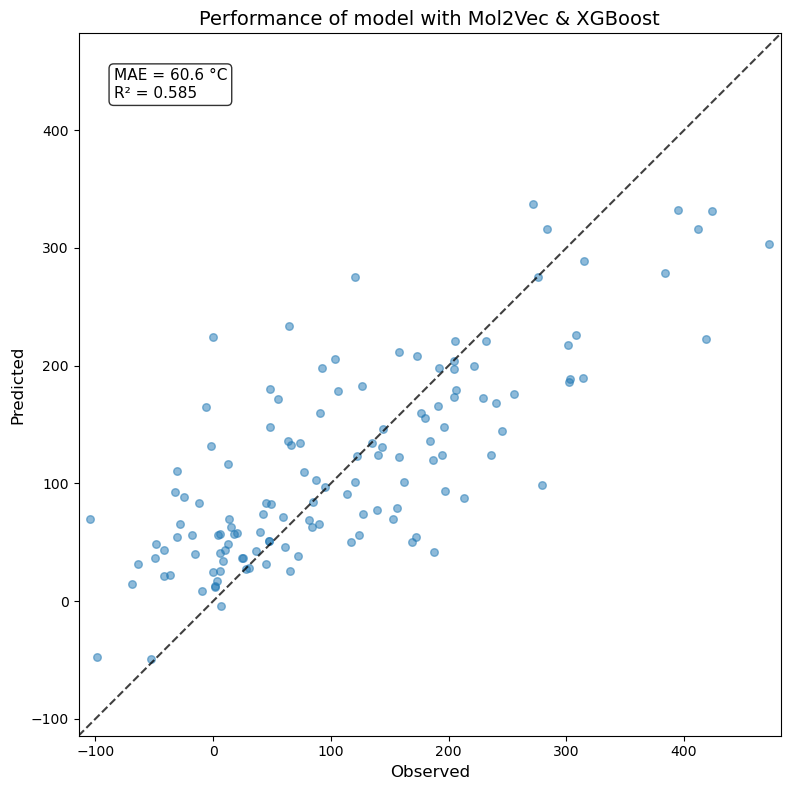

In [9]:
plot_parity(y_test, y_pred_test, 'Performance of model with Mol2Vec & XGBoost')

I have chosen here to report 3 metrics that indicate the effectiveness of the model. As the name suggests, Mean Absolute Error (MAE) indicates on average how far off each prediction is. Root Mean Squared Error (RMSE) also presents prediction error, but it upweights  predictionss that are further from the true values. R<sup>2</sup> captures the proportion of the variance in the target variable that is explained by the model. Each has advantages and disadvantages.  R<sup>2</sup> provides a built-in baseline comparison: it tells you whether the model is actually learning something beyond just predicting the mean. Given the wide range of Tg values in this dataset, that is particularly useful. I show MAE and RMSE for interpretability and to flag large outliers, but I will focus on optimizing R<sup>2</sup>.

## 8. Test model's generalizability

To get a sense for how well the model generalizes beyond the training distribution, we evaluate it against a completely separate dataset. Here we use a dataset of ~1430 polymers from [this 2024 study](https://pmc.ncbi.nlm.nih.gov/articles/PMC11398084/), hosted on [GitHub](https://github.com/PolymerTg/Polymer-Tg-Machine-Learning), which contains experimental Tg measurements for polymers represented as SMILES strings.

We project the new SMILES strings into the same Mol2Vec embedding space and use the resulting vectors to predict Tg values. If the model has learned genuine structure-property relationships rather than memorizing patterns specific to the training data, we would expect R² to remain meaningfully above zero, though likely lower due to differences in the distributions from which the two datasets are drawn.

Embedded 1430/1433 polymers (3 failed)

External Validation (1430 polymers)
----------------------------------------
  MAE:  55.19 °C
  RMSE: 76.10 °C
  R²:   0.266


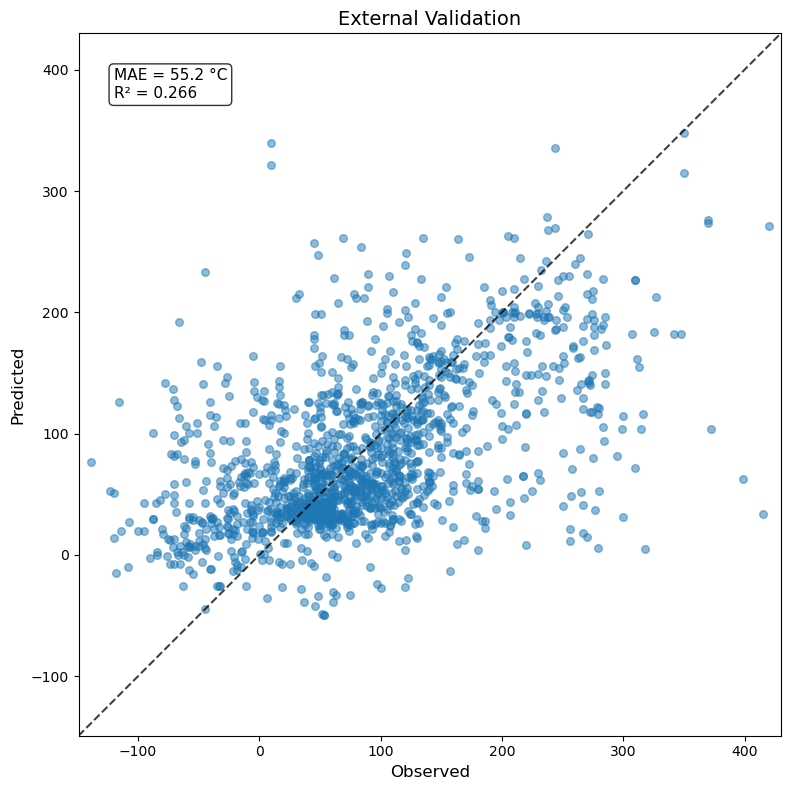

In [14]:
# Load external validation dataset (~1430 polymers from PolymerTg)
# Source: https://github.com/PolymerTg/Polymer-Tg-Machine-Learning
# Download the xlsx manually from the link above and save to data/polymer_tg_external.xlsx
df_ext = pd.read_excel('data/polymer_tg_train.xlsx')

# Standardize column names
smiles_col = [c for c in df_ext.columns if 'smiles' in c.lower()][0]
tg_col = [c for c in df_ext.columns if 'tg' in c.lower()][0]
df_ext = df_ext.rename(columns={smiles_col: 'SMILES', tg_col: 'Tg'})

# Clean Tg values (some entries stored as strings with commas)
df_ext['Tg'] = pd.to_numeric(df_ext['Tg'], errors='coerce')
df_ext = df_ext.dropna(subset=['Tg'])

# Featurize, scale, and predict
X_ext, valid_idx, failed = featurize(df_ext, mol2vec_model)
y_ext = df_ext.loc[valid_idx, 'Tg'].values
X_ext_scaled = scaler.transform(X_ext)
y_ext_pred = model.predict(X_ext_scaled)

print(f'Embedded {len(valid_idx)}/{len(df_ext)} polymers ({len(failed)} failed)')

evaluate(y_ext, y_ext_pred, f'External Validation ({len(valid_idx)} polymers)')
plot_parity(y_ext, y_ext_pred, 'External Validation')

The model achieves an R² of 0.78 on a held-out test set drawn from the same distribution as the training data, suggesting that it captures meaningful structure–property relationships. However, when evaluated against a completely independent dataset of ~1430 polymers, R² drops... a lot. This is expected, since the two datasets are drawn from different sources with (possibly) different polymer families, experimental conditions, and measurement protocols. This kind of distribution shift naturally reduces predictive accuracy, but a positive R² on the external set confirms that the model has learned _some_ generalizable patterns rather than simply memorizing the training data.

## 9. Save trained model to disk

Satisfied with the results, we save the model to disk here.

In [10]:
artifacts = {
    'xgb_model': model,
    'scaler': scaler,
}

with open('trained_model.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print('Saved to trained_model.pkl')

Saved to trained_model.pkl


## 10. Predicting Tg for new polymers

The following code can be used to predict glass transition temperatures for new polymers. To run correctly, it requires a CSV that contains a column called `SMILES`. If the CSV also has a `Tg` column, evaluation metrics will be shown. The following code block shows how to predict with new data. It can be run outside this notebook from the command line like this:

```bash
python model.py --predict path/to/new_polymers.csv
```

This should output a `predictions.csv` file with a `Tg_predicted` column.

In [ ]:
# 1. Load trained model
with open('trained_model.pkl', 'rb') as f:
    artifacts = pickle.load(f)

trained_model = artifacts['xgb_model']
trained_scaler = artifacts['scaler']

# 2. Load new data
## Note that the CSV *must* contain a column called "SMILES". If it also has a 'Tg' column, evaluation metrics will be shown.
new_data = pd.read_csv('data/INSERT NEW DATA HERE.csv')  # <-- replace with new file

# 3. Project SMILES strings into Mol2Vec embedding space and standardize the resulting embeddings
X_new, valid_idx, failed_idx = featurize(new_data, mol2vec_model)
X_new_scaled = trained_scaler.transform(X_new)

# 4. Use XGBoost with early stopping model to predict glass transition temperatures
predictions = trained_model.predict(X_new_scaled)

# 5. Build a new dataframe with data and predicted Tg values
results = new_data.loc[valid_idx].copy()
results['Tg_predicted'] = predictions

# 6. Examine predicted values
print(f'Predicted Tg for {len(results)} polymers')
print(f'{len(failed_idx)} polymers failed to parse')
results[['SMILES', 'Tg_predicted']].head(10)

# 7. Save results to disk
results.to_csv('predictions.csv', index=False)
print('Saved to predictions.csv')